🤖 Machine Learning &nbsp;·&nbsp; *Bài 20/23*

[« Machine Learning - K-means](019_ml_k_means.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Cross Validation »](021_ml_cross_validation.ipynb)

# Machine Learning - Bootstrap Aggregation (Bagging)

> 📖 **Học song song trên W3Schools:** [python_ml_bagging.asp](https://www.w3schools.com/python/python_ml_bagging.asp)
>
> 🎯 **Trong bài này:** Bagging · Evaluating a Base Classifier · Creating a Bagging Classifier · Results Explained · Another Form of Evaluation · Generating Decision Trees from Bagging Classifier

## Bagging

Các phương pháp như **cây quyết định** dễ bị **overfitting** trên tập huấn luyện, dẫn tới dự đoán sai với dữ liệu mới.

**Bootstrap Aggregation (bagging)** là phương pháp **ensemble (kết hợp nhiều mô hình)** nhằm giải quyết overfitting trong bài toán phân loại hoặc hồi quy. Bagging cải thiện độ chính xác và hiệu năng của thuật toán học máy:

1. Lấy các **tập con ngẫu nhiên** của dữ liệu, **có hoàn lại** (bootstrap).
2. Huấn luyện một mô hình trên **mỗi** tập con.
3. **Gộp** dự đoán: lấy **đa số phiếu** (phân loại) hoặc **trung bình** (hồi quy).

## Evaluating a Base Classifier — Đánh giá bộ phân loại cơ sở

Để thấy bagging cải thiện thế nào, trước hết đánh giá một **cây quyết định đơn lẻ** trên tập dữ liệu **wine** của sklearn (phân loại rượu vang thành 3 loại dựa trên thành phần hoá học):

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

data = datasets.load_wine(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=22)

dtree = DecisionTreeClassifier(random_state=22)
dtree.fit(X_train, y_train)

y_pred = dtree.predict(X_test)

print("Train data accuracy:", accuracy_score(y_true=y_train, y_pred=dtree.predict(X_train)))
print("Test data accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))

Train data accuracy: 1.0
Test data accuracy: 0.8222222222222222


Cây quyết định đạt 100% trên tập train nhưng thấp hơn trên tập test → dấu hiệu **overfitting**.

## Creating a Bagging Classifier — Tạo bộ phân loại bagging

Với bagging, cần đặt tham số `n_estimators` — số mô hình cơ sở được gộp lại.

Ta thử nhiều giá trị `n_estimators` để xem hiệu năng thay đổi thế nào:

In [2]:
from sklearn.ensemble import BaggingClassifier

estimator_range = [2, 4, 6, 8, 10, 12, 14, 16]

models = []
scores = []

for n_estimators in estimator_range:
    clf = BaggingClassifier(n_estimators=n_estimators, random_state=22)
    clf.fit(X_train, y_train)
    models.append(clf)
    scores.append(accuracy_score(y_true=y_test, y_pred=clf.predict(X_test)))

print(dict(zip(estimator_range, [round(s, 3) for s in scores])))

{2: 0.822, 4: 0.867, 6: 0.933, 8: 0.933, 10: 0.956, 12: 0.956, 14: 0.956, 16: 0.933}


Trực quan hoá sự cải thiện:

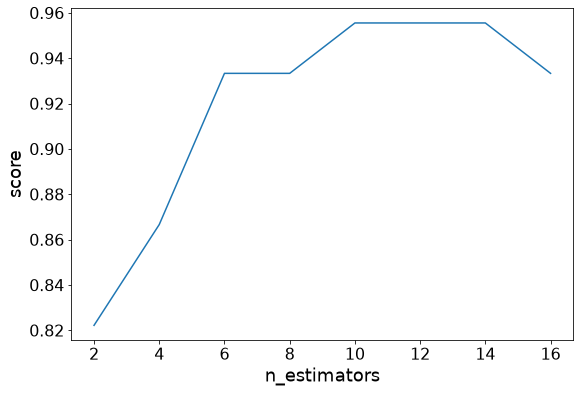

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(estimator_range, scores)

plt.xlabel("n_estimators", fontsize=18)
plt.ylabel("score", fontsize=18)
plt.tick_params(labelsize=16)

plt.show()

## Results Explained — Giải thích kết quả

Thử nhiều giá trị `n_estimators` cho thấy hiệu năng **tăng** so với một cây quyết định đơn lẻ, rồi chững lại khi đủ nhiều mô hình.

> 💡 Chọn `random_state` khác nhau sẽ cho kết quả khác — hãy dùng **cross validation** để có đánh giá ổn định hơn.

## Another Form of Evaluation — Đánh giá bằng Out-of-Bag

Vì bootstrap chọn tập con **có hoàn lại**, một số mẫu **không** được chọn cho mỗi mô hình. Các mẫu đó gọi là **out-of-bag (OOB)**, có thể dùng để đánh giá mô hình — giống như một tập test:

In [4]:
oob_model = BaggingClassifier(n_estimators=12, oob_score=True, random_state=22)

oob_model.fit(X_train, y_train)

print(oob_model.oob_score_)

0.9398496240601504


## Generating Decision Trees from Bagging Classifier — Xem một cây trong bagging

Có thể xem từng cây quyết định cấu thành mô hình bagging:

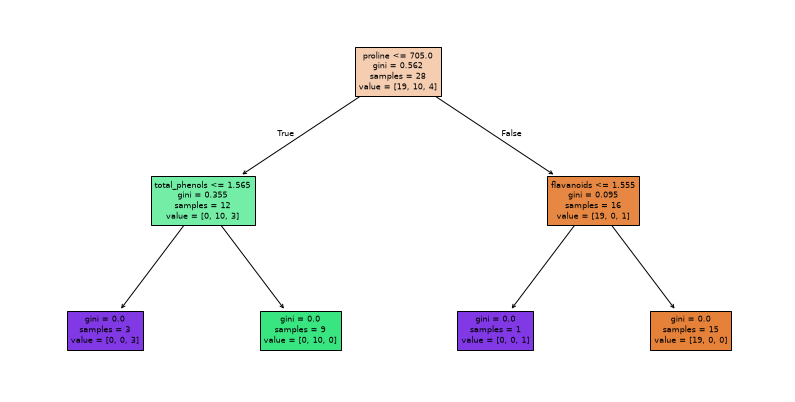

In [5]:
from sklearn.tree import plot_tree

clf = BaggingClassifier(n_estimators=12, oob_score=True, max_samples=0.25, random_state=22)
clf.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(clf.estimators_[0], feature_names=list(X.columns), filled=True, fontsize=8)
plt.show()

> 📌 Mặc định `BaggingClassifier` dùng `DecisionTreeClassifier` làm mô hình cơ sở. Muốn đổi, truyền `estimator=...` (scikit-learn mới đã bỏ tên cũ `base_estimator`).

---

## 🧠 Ghi nhớ nhanh

> - Bagging = huấn luyện **nhiều mô hình** trên các tập con lấy mẫu **có hoàn lại**, rồi gộp kết quả (bỏ phiếu/trung bình).
> - Giảm **overfitting** của cây quyết định: `BaggingClassifier(n_estimators=..., random_state=...)`.
> - `oob_score=True` → đánh giá bằng mẫu **out-of-bag** (`.oob_score_`).

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Bagging giúp giải quyết vấn đề gì của cây quyết định?

- **A.** Chạy quá chậm
- **B.** Không xử lý được số
- **C.** Overfitting (quá khớp dữ liệu huấn luyện)
- **D.** Thiếu dữ liệu

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: C** — Overfitting (quá khớp dữ liệu huấn luyện)

</details>

---

[« Machine Learning - K-means](019_ml_k_means.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Cross Validation »](021_ml_cross_validation.ipynb)